In [120]:
# ==============================================================
# WCTE PMT ANALYSIS NOTEBOOK – MERGED PIPELINE
# ==============================================================
import os, re, random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.stats import norm, gaussian_kde
from scipy.optimize import curve_fit, minimize
from scipy.signal import argrelextrema
from tqdm import tqdm
import pandas as pd
from math import factorial

# --------------------------------------------------------------
# Matplotlib styling
rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [11, 8]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 16
rcParams['ytick.labelsize'] = 16

# ==============================================================
# ========================== FUNCTIONS =========================
# ==============================================================
# ===============================
# FUNCTIONS (UPDATED FOR MULTI-PE)
# ===============================

def do_pulse_finding(waveform, debug=False):
    threshold = 20
    fIntegralPreceding = 4
    fIntegralFollowing = 2
    
    above_threshold = np.where(waveform[3:-2] > threshold)[0] + 3
    pulses_found = []
    last_index = 0
    
    for index in above_threshold:
        if (waveform[index] <= waveform[index-1]): continue
        if (waveform[index] < waveform[index+1]): continue
        if (waveform[index] <= waveform[index+2]): continue
        if (waveform[index] <= waveform[index-2]): continue
        
        start = max(0, index - fIntegralPreceding)
        end = min(len(waveform), index + fIntegralFollowing + 1)
        integral = np.sum(waveform[start:end])
        if integral < threshold * 2:
            continue
        
        if (last_index > 0) and (index - last_index) <= 20:
            continue
        
        pulses_found.append(index)
        last_index = index
    
    return pulses_found


def charge_calculation_mPMT_method(wf, peak_sample):
    n = len(wf)
    start = max(0, peak_sample - 5)
    end = min(n, peak_sample + 2)
    charge = np.sum(wf[start:end])
    if peak_sample + 2 < n and wf[peak_sample + 2] > 0:
        charge += wf[peak_sample + 2]
    return charge


# ----------------------------------
# SAFE Gaussian fit (NO HARD FAIL)
# ----------------------------------
def fit_gaussian_with_bounds(data, mu0, sigma0, sigma_bounds):

    N = len(data)
    if N < 10:
        return dict(
            mu=np.median(data) if N > 0 else 0.0,
            sigma=np.std(data) if N > 1 else 1.0,
            A=N,
            err_mu=np.inf,
            err_sigma=np.inf,
            n=N,
            failed=True
        )

    A0 = N
    bounds = [(-np.inf, np.inf), sigma_bounds, (1, np.inf)]

    def nll(params):
        mu, sigma, A = params
        if sigma <= 0 or A <= 0:
            return np.inf
        pdf = A * norm.pdf(data, mu, sigma)
        return -np.sum(np.log(np.clip(pdf, 1e-12, None)))

    res = minimize(nll, [mu0, sigma0, A0], method="L-BFGS-B", bounds=bounds)

    if not res.success:
        return dict(
            mu=np.median(data),
            sigma=np.std(data),
            A=N,
            err_mu=np.inf,
            err_sigma=np.inf,
            n=N,
            failed=True
        )

    mu_fit, sigma_fit, A_fit = res.x
    return dict(
        mu=mu_fit,
        sigma=sigma_fit,
        A=A_fit,
        err_mu=sigma_fit / np.sqrt(N),
        err_sigma=sigma_fit / np.sqrt(2*N),
        n=N,
        failed=False
    )


# ----------------------------------
# Pedestal + SPE (NO HARD FAIL)
# ----------------------------------
def fit_pedestal_and_spe(charges, label="PMT", plot=True):

    x = np.asarray(charges)
    if len(x) < 80:
        return None

    xs = np.linspace(np.min(x), np.max(x), 2500)
    kde = gaussian_kde(x)
    ys = kde(xs)
    peak_idx = argrelextrema(ys, np.greater)[0]

    ped_center = 0.0
    spe_center = None

    try:
        expected_spe_min = 100.0
        expected_spe_max = 200.0
        peak_xs = xs[peak_idx]
        peak_ys = ys[peak_idx]

        spe_mask = (peak_xs >= expected_spe_min) & (peak_xs <= expected_spe_max)
        spe_idx = np.where(spe_mask)[0]

        if len(spe_idx) > 0:
            i = spe_idx[np.argmax(peak_ys[spe_idx])]
            spe_center = peak_xs[i]
            ped_center = np.min(peak_xs[peak_xs < spe_center])
        else:
            raise RuntimeError

    except Exception:
        spe_candidates = x[(x >= 100) & (x <= 200)]
        if len(spe_candidates) == 0:
            return None
        spe_center = np.median(spe_candidates)
        ped_center = 0.0

    ped_mask = np.abs(x - ped_center) < 10
    ped_data = x[ped_mask]

    spe_mask = np.abs(x - spe_center) < 60
    spe_data = x[spe_mask]

    if len(spe_data) < 20:
        return None

    pedestal_fit = fit_gaussian_with_bounds(
        ped_data,
        np.median(ped_data) if len(ped_data) else 0.0,
        np.std(ped_data) if len(ped_data) > 1 else 1.0,
        (0.1, 10.0)
    )

    spe_fit = fit_gaussian_with_bounds(
        spe_data,
        np.median(spe_data),
        max(20, np.std(spe_data)),
        (5, 300)
    )

    gain = spe_fit["mu"] - ped_center
    err_gain = np.sqrt(
        (pedestal_fit["err_mu"] if np.isfinite(pedestal_fit["err_mu"]) else 0)**2 +
        spe_fit["err_mu"]**2
    )

    result = dict(
        pedestal=pedestal_fit,
        spe=spe_fit,
        gain=gain,
        err_gain=err_gain,
        n_ped=len(ped_data),
        n_spe=len(spe_data)
    )

    if plot:
        bins = np.linspace(np.min(x), np.max(x), 500)
        bc = 0.5*(bins[1:] + bins[:-1])
        bw = bins[1] - bins[0]
        fig, ax = plt.subplots(figsize=(9,6), dpi=150)
        ax.hist(x, bins=bins, histtype="step", color="black", lw=1, label="Data")
        ped_pdf = pedestal_fit["n"] * norm.pdf(bc, pedestal_fit["mu"], pedestal_fit["sigma"]) * bw
        spe_pdf  = spe_fit["n"] * norm.pdf(bc,  spe_fit["mu"],  spe_fit["sigma"]) * bw
        ax.plot(bc, ped_pdf, "b--", lw=1.5, label=f"Pedestal μ={pedestal_fit['mu']:.2f}, σ={pedestal_fit['sigma']:.2f}, N={len(ped_data)}")
        ax.plot(bc, spe_pdf,  "g--", lw=1.5, label=f"SPE μ={spe_fit['mu']:.2f}, σ={spe_fit['sigma']:.2f}, N={len(spe_data)}")
        ax.plot(bc, ped_pdf + spe_pdf, "r", lw=1, alpha=0.7, label=f"Sum (Gain = {gain:.2f} ± {err_gain:.2f})")
        ax.set_xlim(-20, 500)
        ax.set_ylim(0, 300)
        ax.set_xlabel("Integrated charge [ADC·ns]")
        ax.set_ylabel(f"counts / {bw:.2f} ADC·ns")
        ax.set_title(f"Run {run_number}, pulse width {pulse_width}ps - PMT {pmt_label}: Unbinned Gaussian fit for seeds")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=rcParams['legend.fontsize'])
        plt.show()

    return result


# ===============================
# MULTI-PE SEQUENTIAL FIT
# ===============================

def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

def fit_multi_pe_sequential(charges, seeds, n_max=5, bins=500, plot=True):
    """
    Fit sequential multi-PE peaks using n*mu1, sqrt(n)*sigma1 as seeds,
    with restricted regions for each n>1.
    Only peaks with N>0 are kept and plotted.
    """
    x = np.asarray(charges)
    counts, edges = np.histogram(x, bins=bins)
    bin_centers = 0.5*(edges[1:] + edges[:-1])
    bw = bin_centers[1] - bin_centers[0]

    mu0, sigma0 = seeds['pedestal']['mu'], seeds['pedestal']['sigma']
    mu1, sigma1 = seeds['spe']['mu'], seeds['spe']['sigma']

    peaks = {}  # mu_n, sigma_n, A_n for each n
    total_fit_curve = np.zeros_like(bin_centers, dtype=float)

    # 0-PE
    mask0 = (bin_centers >= mu0 - 3*sigma0) & (bin_centers <= mu0 + 3*sigma0)
    x_fit0, y_fit0 = bin_centers[mask0], counts[mask0]
    try:
        p0 = [np.max(y_fit0), mu0, sigma0]
        bounds = ([0, mu0-5*sigma0, 0.05],[np.inf, mu0+5*sigma0, 10])
        params, _ = curve_fit(gaussian, x_fit0, y_fit0, p0=p0, bounds=bounds, maxfev=20000)
        A0, mu0_fit, sigma0_fit = params
    except:
        mu0_fit, sigma0_fit, A0 = mu0, sigma0, np.max(y_fit0)
    N0 = int(A0 * sigma0_fit * np.sqrt(2*np.pi))
    if N0 > 0:
        peaks[0] = (mu0_fit, sigma0_fit, A0)
        total_fit_curve += gaussian(bin_centers, A0, mu0_fit, sigma0_fit)

    # 1-PE
    mask1 = (bin_centers >= mu1 - 1.2*sigma1) & (bin_centers <= mu1 + 80)
    x_fit1, y_fit1 = bin_centers[mask1], counts[mask1]
    try:
        p0 = [np.max(y_fit1), mu1, sigma1]
        bounds = ([0, mu1-3*sigma1, 5],[np.inf, mu1+3*sigma1, 80])
        params, _ = curve_fit(gaussian, x_fit1, y_fit1, p0=p0, bounds=bounds, maxfev=20000)
        A1, mu1_fit, sigma1_fit = params
    except:
        mu1_fit, sigma1_fit, A1 = mu1, sigma1, np.max(y_fit1)
    N1 = int(A1 * sigma1_fit * np.sqrt(2*np.pi))
    if N1 > 0:
        peaks[1] = (mu1_fit, sigma1_fit, A1)
        total_fit_curve += gaussian(bin_centers, A1, mu1_fit, sigma1_fit)

    # n-PE n>=2
    for n in range(2, n_max+1):
        mu_n_seed = n*mu1_fit
        sigma_n_seed = np.sqrt(n)*sigma1_fit
        low, high = mu_n_seed-40, mu_n_seed+60
        mask_n = (bin_centers >= low) & (bin_centers <= high)
        x_fit_n, y_fit_n = bin_centers[mask_n], counts[mask_n]

        if len(x_fit_n) > 0:
            try:
                p0 = [np.max(y_fit_n), mu_n_seed, sigma_n_seed]
                bounds = ([0, mu_n_seed-0.3*mu1_fit, 0.1],[np.inf, mu_n_seed+0.3*mu1_fit, 80])
                params, _ = curve_fit(gaussian, x_fit_n, y_fit_n, p0=p0, bounds=bounds, maxfev=20000)
                A_n, mu_n_fit, sigma_n_fit = params
            except:
                mu_n_fit, sigma_n_fit, A_n = mu_n_seed, sigma_n_seed, np.max(y_fit_n)
        else:
            mu_n_fit, sigma_n_fit, A_n = mu_n_seed, sigma_n_seed, 0

        N_n = int(A_n * sigma_n_fit * np.sqrt(2*np.pi))
        if N_n > 0:
            peaks[n] = (mu_n_fit, sigma_n_fit, A_n)
            total_fit_curve += gaussian(bin_centers, A_n, mu_n_fit, sigma_n_fit)

    # PLOT
    if plot:
        xx = np.linspace(-20, 1000, 2000)
        plt.figure(figsize=(9,6), dpi=150)
        plt.hist(x, bins=bins, histtype='step', color='black', lw=1, alpha=0.8, label='Data')

        colors_list = ['blue','cyan','orange','purple','brown','green']
        for i, (n, (mu, sigma, A)) in enumerate(peaks.items()):
            N_events = int(A * sigma * np.sqrt(2*np.pi))
            plt.plot(xx, gaussian(xx, A, mu, sigma), '--',
                     color=colors_list[i % len(colors_list)],
                     lw=1.5,
                     label=f"{n}-PE μ={mu:.2f}, σ={sigma:.2f}, N={N_events}")
            plt.axvspan(mu-2.5*sigma, mu+2.5*sigma, alpha=0.08, color=colors_list[i % len(colors_list)])

        # TOTAL FIT CURVE
        plt.plot(bin_centers, total_fit_curve, 'r-', lw=1, label='Total fit')

        plt.xlabel('Integrated charge [ADC·ns]')
        plt.ylabel(f'counts / {bw:.2f} ADC·ns')
        plt.xlim(-20, 1000)
        plt.ylim(0,50)
        plt.grid(alpha=0.3)
        plt.legend(fontsize=rcParams['legend.fontsize'])
        plt.title(f'Run {run_number} – PMT {pmt_label}. Multi-PE fit')
        plt.show()

    return peaks


In [121]:

# ==============================================================
# ======================= LOAD DATA ===========================
# ==============================================================
signal_dir = "/scratch/elena/WCTE_DATA_ANALYSIS/waveform_npz/run2307"
pattern = re.compile(r"card(\d+)_slot(\d+)_ch(\d+)_pos(\d+)\.npz$")
available_pmts = []

for fname in os.listdir(signal_dir):
    match = pattern.match(fname)
    if match:
        available_pmts.append(tuple(map(int, match.groups())))

available_pmts = sorted(available_pmts)
print(f"Found {len(available_pmts)} PMT files.")

# Random PMT selection
card_id, slot_id, ch_id, pos_id = random.choice(available_pmts)
matching = [pos for c,s,ch,pos in available_pmts if c==card_id and s==slot_id and ch==ch_id]
if len(matching) != 1: raise ValueError("PMT selection ambiguous")
pos_id = matching[0]

combined_file = os.path.join(signal_dir, f"card{card_id}_slot{slot_id}_ch{ch_id}_pos{pos_id}.npz")
data = np.load(combined_file, allow_pickle=True)
signal_waveforms = data["waveforms"]
print(f"Loaded signal waveforms: {signal_waveforms.shape}")

run_number = int(re.search(r"run(\d+)", signal_dir).group(1))
pulse_width = 810
pmt_label = f"card{card_id}_slot{slot_id}_ch{ch_id}"
print(f"Run: {run_number}, pulse_width: {pulse_width}, pmt_label: {pmt_label}")

# ==============================================================
# ================== PROCESS WAVEFORMS ========================
# ==============================================================

all_peaks = [do_pulse_finding(wf) for wf in signal_waveforms]
pulse_mask = np.array([len(p)>0 for p in all_peaks])
noise_mask = ~pulse_mask

charges = []
peak_values = []

for wf, peaks in tqdm(zip(signal_waveforms, all_peaks), total=len(signal_waveforms), desc="Integrating waveforms"):
    peak_sample = peaks[0] if len(peaks)>0 else np.argmax(wf)
    charges.append(charge_calculation_mPMT_method(wf, peak_sample))
    peak_values.append(wf[peak_sample])

charges = np.array(charges)
peak_values = np.array(peak_values)

pulse_count = np.sum(pulse_mask)
noise_count = np.sum(noise_mask)
pulse_ratio = pulse_count/len(signal_waveforms)
mu = -np.log(1-pulse_ratio)

print(f"Total waveforms: {len(signal_waveforms)} | Pulses: {pulse_count} | Noise: {noise_count} | Pulse ratio: {pulse_ratio:.4f} | mu_pe={mu:.4f}")

Found 1567 PMT files.
Loaded signal waveforms: (6000, 64)
Run: 2307, pulse_width: 810, pmt_label: card27_slot2_ch3


Integrating waveforms: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6000/6000 [00:00<00:00, 36676.00it/s]

Total waveforms: 6000 | Pulses: 1216 | Noise: 4784 | Pulse ratio: 0.2027 | mu_pe=0.2265


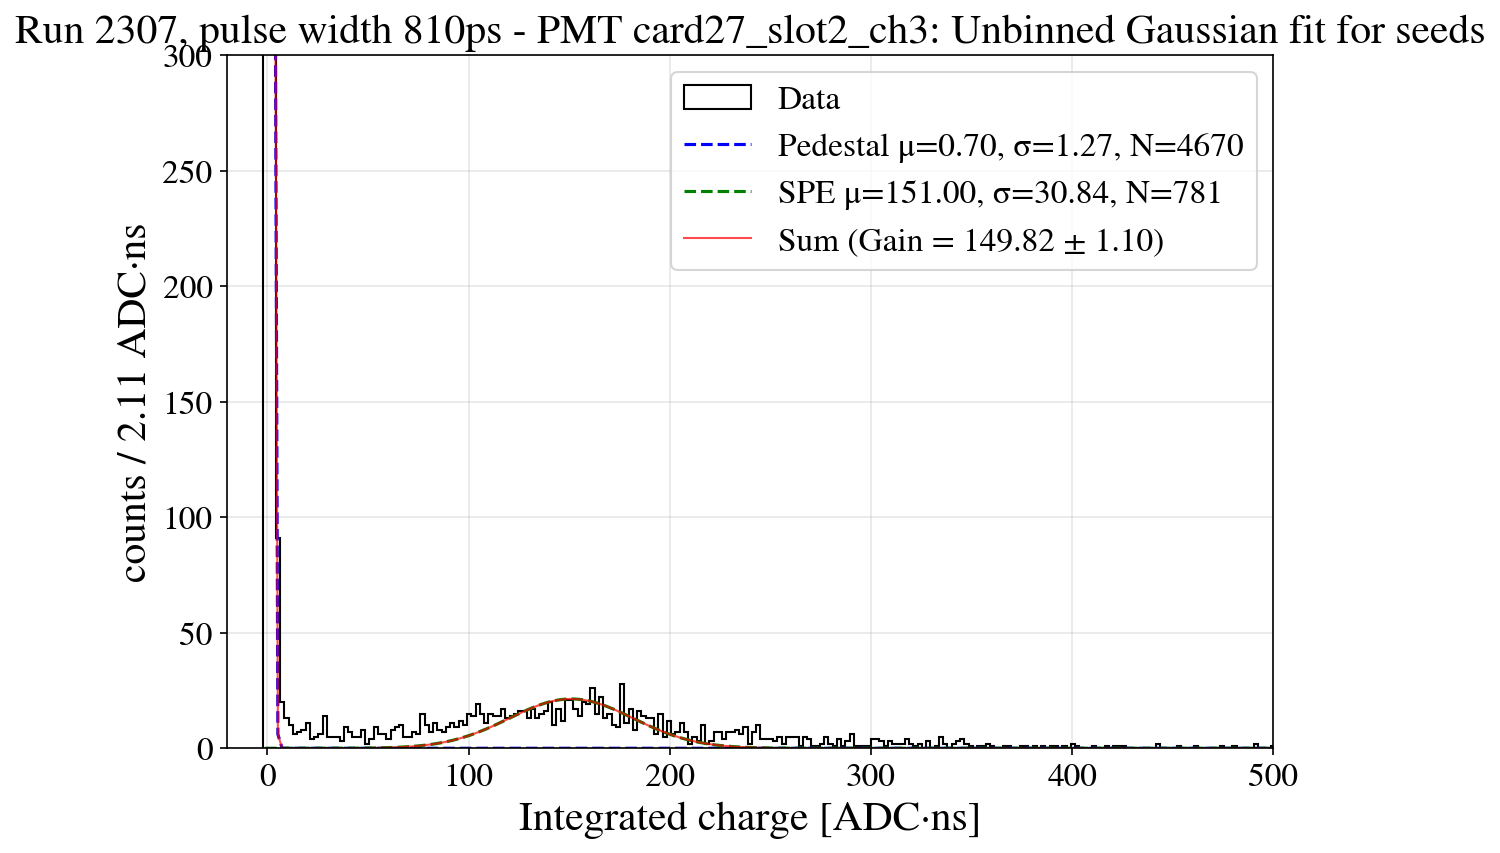

Pedestal: mu=0.70, sigma=1.27
SPE: mu=151.00, sigma=30.84, Gain=149.82 ± 1.10


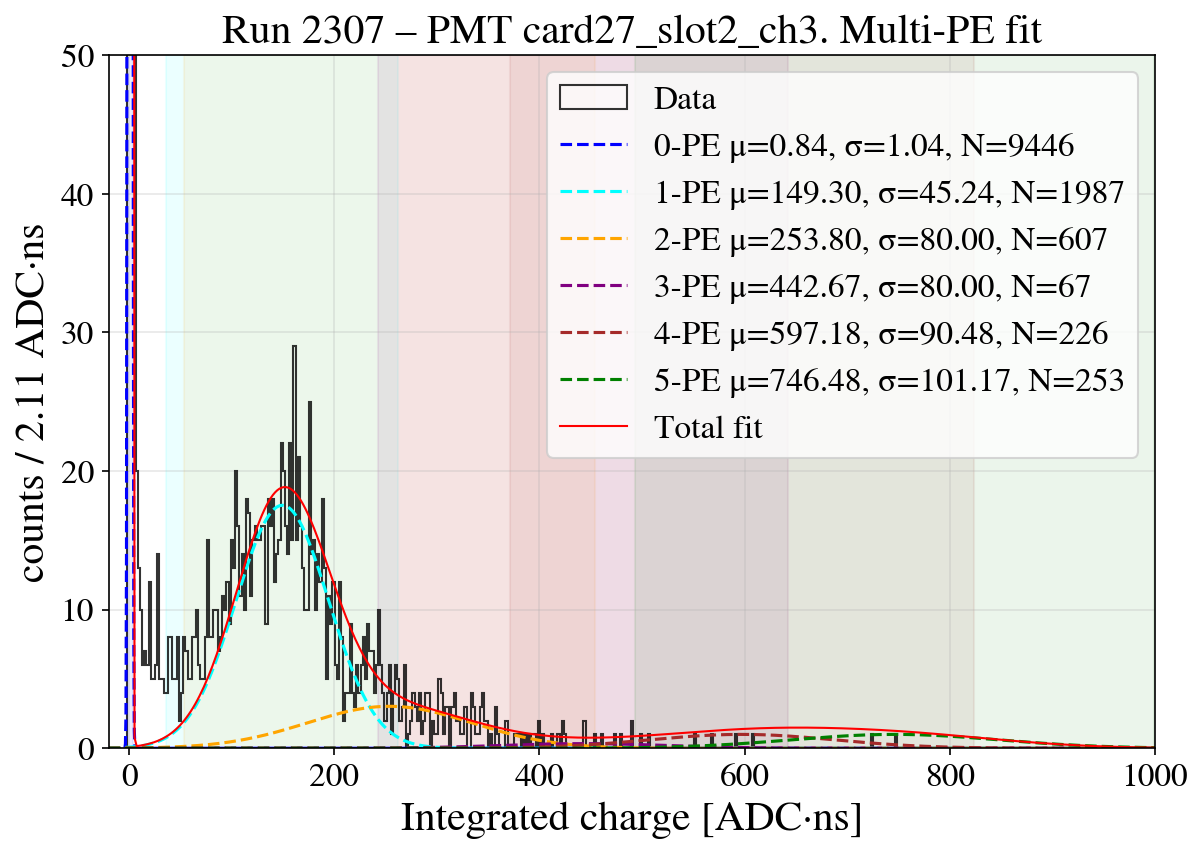


=== FINAL MULTI-PE FIT RESULTS ===
0-PE: mu=0.84, sigma=1.04, N=9446
1-PE: mu=149.30, sigma=45.24, N=1987
2-PE: mu=253.80, sigma=80.00, N=607
3-PE: mu=442.67, sigma=80.00, N=67
4-PE: mu=597.18, sigma=90.48, N=226
5-PE: mu=746.48, sigma=101.17, N=253


In [122]:
# ==============================================================
# ===================== CALCULAR SEEDS ========================
# ==============================================================
seeds = fit_pedestal_and_spe(charges, label=pmt_label, plot=True)

if seeds is None:
    raise RuntimeError("No se pudieron calcular las seeds para pedestal/SPE.")

print(f"Pedestal: mu={seeds['pedestal']['mu']:.2f}, sigma={seeds['pedestal']['sigma']:.2f}")
print(f"SPE: mu={seeds['spe']['mu']:.2f}, sigma={seeds['spe']['sigma']:.2f}, Gain={seeds['gain']:.2f} ± {seeds['err_gain']:.2f}")

# ==============================================================
# ==================== MULTI-PE GLOBAL FIT =====================
# ==============================================================
n_max_pe = 5
multi_pe_results = fit_multi_pe_sequential(charges, seeds, n_max=n_max_pe, bins=500, plot=True)

# Filtramos picos con N>0 para reportarlos
print("\n=== FINAL MULTI-PE FIT RESULTS ===")
for n, (mu, sigma, A) in multi_pe_results.items():
    N_events = int(A * sigma * np.sqrt(2*np.pi))
    if N_events > 0:
        print(f"{n}-PE: mu={mu:.2f}, sigma={sigma:.2f}, N={N_events}")
